<a href="https://colab.research.google.com/github/alexyh1/STA4000/blob/main/code/McCann_Interpolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The following code is a numerical implementation following McCann's Displacement Interpolation (Definition 1.19) from STA4000 Supervised Reading Project: Optimal Transport for Machine Learners. More examples can be found here: https://github.com/alexyh1/STA4000/tree/main/code

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma, gaussian_kde
import time

We explore a simple example of McCann's Interpolation Theorem which gives us the geodesic between two probability measures. Recall for Borel probability measures $μ, ν$ in $\mathbb{R}$ absolutely continuous wrt Lebesgue measure, the Monge problem is given as $$ \mathcal{M}_c(\mu, \nu) = \inf_{T: \mathbb{R} → \mathbb{R}} \{\displaystyle \int_{\mathbb{R}} c(x, T(x)) d\mu(x), T_\#\mu = \nu \}$$
Where $c(x, y) = \lvert x - y \rvert^2$ is commonly assumed. The push-forward constraint is equivalent to $\nu(B) = \mu(T^{-1}(B))$ for Borel sets $B$.

For 1D distributions, the Monge transport map has a closed-form solution given by $T = \mathcal{C}_\nu^{-1} \circ \mathcal{C}_\mu$ where $\mathcal{C}_\mu$ and $\mathcal{C}_\nu^{-1}$ are the cdf and quantile function of $\mu$ and $\nu$ respctively.

We proceed with a simple numerical example where $\mu \sim N(0, 1)$ and $\nu \sim \Gamma(1, 1)$.


In [ ]:
start_time = time.time()
np.random.seed(4000)

# Initialize probability measure
n = 100000
X = np.random.normal(0, 1, n)
u = norm.cdf(X)

# Push-forward map
v = gamma.ppf(u, 1, 1)

The McCann Displacement Interpolation generated by $T$ is the curve $$T_t(x) = (1-t)x+tT(x), \ (T_t)_\# \mu = \mu_t$$ Which can be thought of as mapping out intermediate probability measures when transporting from $\mu$ to $\nu$. Notice that since $t \rightarrow \mu_t$ is a geodesic then $T_t$ is the Monge map that transports $\mu$ to $\mu_t$.

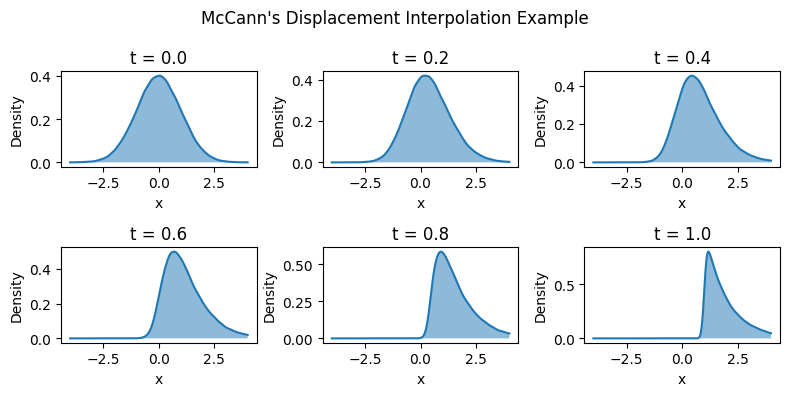

In [ ]:
times = np.linspace(0, 1, num = 6)
fig, axs = plt.subplots(2, 3, figsize = (8, 4))
xgrid = np.linspace(-4, 4, 500)

for t, ax in zip(times, axs.flat):
  # Kernel density smoothing
  kde = gaussian_kde((1-t)*X + t*v)
  ax.plot(xgrid, kde(xgrid))
  ax.fill_between(xgrid, kde(xgrid), alpha = 0.5)
  ax.set_title(f"t = {round(t, 2)}")
  ax.set_xlabel('x')
  ax.set_ylabel('Density')

plt.suptitle("McCann's Displacement Interpolation Example")
plt.tight_layout()
plt.show()


The figure above returns the density functions of the probability measures along the geodesic for values equidistant values $t$.

In [ ]:
end_time = time.time()
print(f"Program runtime: {end_time - start_time:.3f} seconds.")

Program runtime: 16.065 seconds.


##**References**
[1] G. Peyré (2026). [*Optimal Transport for Machine Learners*.](https://arxiv.org/pdf/2505.06589) arXiv preprint arXiv:2505.06589.

[2] R. McCann (1997). [*A Convexity Principle for Interacting Gases*](https://www.ceremade.dauphine.fr/~carlier/McCann-convexity-displ.pdf). Advanced in Mathematics 128 (1997): 153-179.
